In [1]:
#Importacion de librerias
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

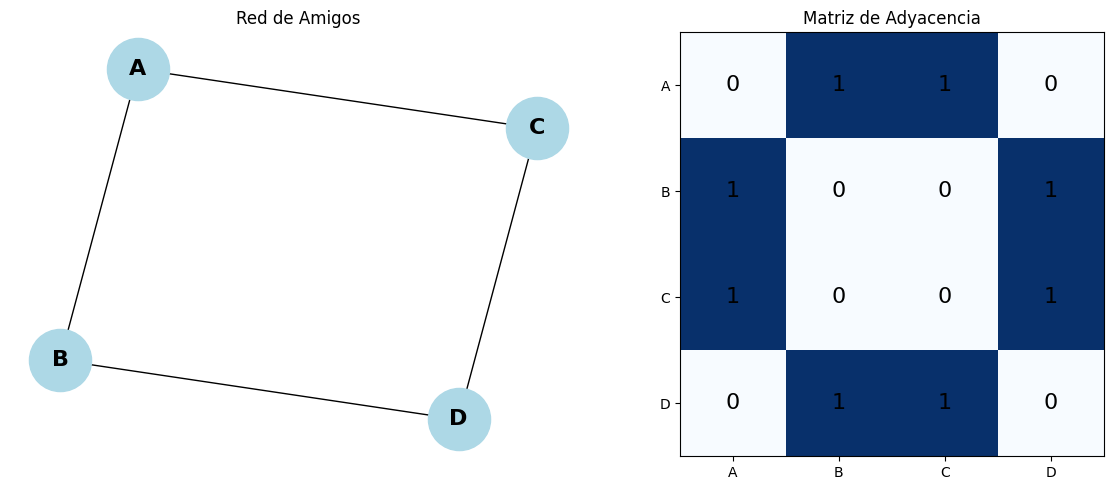

Matriz de adyacencia:
   A  B  C  D
A [0 1 1 0]
B [1 0 0 1]
C [1 0 0 1]
D [0 1 1 0]

Lista de adyacencia:
A: B, C
B: A, D
C: A, D
D: B, C


In [6]:
# Crear el grafo
G = nx.Graph()

# Definir las relaciones de amistad
amistades = {
    'A': ['B', 'C'],
    'B': ['A', 'D'],
    'D': ['B', 'C'],
    'C': ['A', 'D']
}

# Añadir las relaciones al grafo
for persona, amigos in amistades.items():
    for amigo in amigos:
        G.add_edge(persona, amigo)

# Crear la matriz de adyacencia
nodos = sorted(G.nodes())
matriz_adyacencia = nx.adjacency_matrix(G, nodelist=nodos).todense()

# Configurar la visualización
plt.figure(figsize=(12, 5))

# Subplot 1: Grafo de redes de amigos
plt.subplot(121)
pos = nx.spring_layout(G)  # Posiciones para todos los nodos
nx.draw(G, pos, with_labels=True, node_color='lightblue', 
        node_size=2000, font_size=16, font_weight='bold')
plt.title('Red de Amigos')

# Subplot 2: Matriz de adyacencia
plt.subplot(122)
plt.imshow(matriz_adyacencia, cmap='Blues', interpolation='nearest')
plt.xticks(range(len(nodos)), nodos)
plt.yticks(range(len(nodos)), nodos)
plt.title('Matriz de Adyacencia')

# Añadir valores numéricos a la matriz
for i in range(len(nodos)):
    for j in range(len(nodos)):
        plt.text(j, i, int(matriz_adyacencia[i, j]), 
                 ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()

# Mostrar información adicional en consola
print("Matriz de adyacencia:")
print("   " + "  ".join(nodos))
for i, nodo in enumerate(nodos):
    print(f"{nodo} {matriz_adyacencia[i]}")
    
print("\nLista de adyacencia:")
for nodo in nodos:
    amigos = list(G.neighbors(nodo))
    print(f"{nodo}: {', '.join(amigos)}")

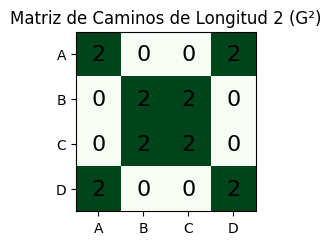

In [5]:
# Calcular G² (matriz de caminos de longitud 2)
matriz_caminos_2 = np.dot(matriz_adyacencia, matriz_adyacencia)
# Subplot 3: Matriz de caminos de longitud 2 (G²)
plt.subplot(133)
plt.imshow(matriz_caminos_2, cmap='Greens', interpolation='nearest')
plt.xticks(range(len(nodos)), nodos)
plt.yticks(range(len(nodos)), nodos)
plt.title('Matriz de Caminos de Longitud 2 (G²)')

# Añadir valores numéricos a la matriz G²
for i in range(len(nodos)):
    for j in range(len(nodos)):
        plt.text(j, i, int(matriz_caminos_2[i, j]), 
                 ha='center', va='center', fontsize=16)

plt.tight_layout()
plt.show()